# Sentiment Analysis of Brainrot YouTube Comments
### Transformer-based Emotion and Irony Detection

---

**Research Hypothesis:**
> *Internet users engage with brainrot culture through irony-heavy humor mixed with underlying concern about attention and overstimulation.*

**Research Questions:**
- **RQ1:** Do comments that use meme slang (skibidi, rizz, etc.) skew ironic or humorous compared to the broader corpus?
- **RQ2:** Do comments referencing cognitive effects (ADHD, attention span) and platform addiction (dopamine, scrolling) skew toward concern or fear?
- **RQ3:** Is there a statistical pattern of irony co-occurring with concern within individual comments?


That's all 36 cells. The notebook runs top to bottom, but Cell 4-D saves sentiment_scores.csv as a checkpoint — if you restart the kernel after that point, just uncomment the reload lines in that cell and skip Sections 3 and 4 entirely.

## Method Overview

Two HuggingFace transformer models are applied to the 6,241 cleaned YouTube comments from `comments_cleaned.csv`:

| Model | ID | Task | Output |
|---|---|---|---|
| Emotion | `j-hartmann/emotion-english-distilroberta-base` | 7-class emotion | anger, disgust, fear, joy, neutral, sadness, surprise |
| Irony | `cardiffnlp/twitter-roberta-base-irony` | Binary | P(ironic) |

**Emotion → Research Dimension mapping:**

| Raw Label | Research Dimension |
|---|---|
| joy | humor |
| fear + sadness (avg) | concern |
| anger + disgust (avg) | criticism |
| neutral | neutral |

Category tags from `nlp.ipynb` are re-applied via keyword matching to link emotion scores to the five slang themes. This notebook reads `comments_cleaned.csv` and writes `sentiment_scores.csv` — no existing files are modified.


## Limitations (read before interpreting results)

1. **Domain mismatch (irony model):** `twitter-roberta-base-irony` was trained on SemEval 2018 Twitter data. YouTube comments are longer, use reply threading, and express irony through meme-specific patterns (e.g., `💀💀`, deliberate overstatement). Irony scores are directional signals, not ground truth.

2. **Keyword coverage:** The five slang categories collectively cover ~22.5% of the corpus. Category-level findings apply to that keyword-tagged minority, not the full 6,241 comments.

3. **Token truncation:** 8 comments exceed the 512-token limit; their sentiment is scored on the first ~512 tokens only.

4. **Lowercased input issue:** `clean_comment` is fully lowercased. A separate `transformer_input` column is derived from the original `comment_text` to preserve case signals (emphatic caps, proper nouns like TikTok).

5. **Engagement floor:** 32% of comments have 0 likes, conflating unseen comments with genuinely unpopular ones.


In [1]:
!pip install seaborn scikit-learn


In [2]:
# First, install the transformers library (run this in a cell)
!pip install transformers

In [3]:
!pip install torch

In [4]:
import pandas as pd
import numpy as np
import re
import html
import gc
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from transformers import pipeline
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("Imports complete.")


Imports complete.


## Section 2 — Data Loading and Transformer Input

`clean_comment` is fully lowercased (done in `preprocessing.ipynb`). Since both transformer models were pre-trained on mixed-case social media text, using lowercased input degrades performance — particularly for emphatic capitalisation (`"THIS IS ACTUAL BRAIN ROT"`) and proper nouns (`TikTok`, `Gen Z`). A `transformer_input` column is derived from the original `comment_text` with only minimal cleaning: HTML entity decoding, URL removal, and whitespace normalisation.


In [5]:
df = pd.read_csv("comments_cleaned.csv")
print(f"Loaded {len(df):,} comments across {df['video_id'].nunique()} videos")
print(f"Columns: {list(df.columns)}")
df.head(3)


Loaded 6,241 comments across 22 videos
Columns: ['video_id', 'video_title', 'author', 'comment_text', 'comment_published_at', 'comment_like_count', 'clean_comment', 'comment_length_chars', 'comment_length_words']


,video_id,video_title,author,comment_text,comment_published_at,comment_like_count,clean_comment,comment_length_chars,comment_length_words
0,laZpTO7IFtA,Is 67 just brain rot?,@ExoticNibbles2,Nothing makes me feel older then watching a 15...,2025-10-14T22:24:09Z,7902,nothing makes me feel older then watching a 15...,109,20
1,laZpTO7IFtA,Is 67 just brain rot?,@andrewbunnell7576,6 x 7 = 42 The answer to Life the Universe and...,2025-10-13T20:12:09Z,7692,6 x 7 = 42 the answer to life the universe and...,57,13
2,laZpTO7IFtA,Is 67 just brain rot?,@ColinPaddock,All I know is 6 is afraid of 7.,2025-10-14T06:39:54Z,6194,all i know is 6 is afraid of 7.,31,9


In [6]:
def prepare_transformer_input(text: str) -> str:
    text = html.unescape(str(text))
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    return re.sub(r"\s+", " ", text).strip()

df["transformer_input"] = df["comment_text"].apply(prepare_transformer_input)
texts = df["transformer_input"].tolist()
print(f"Prepared {len(texts):,} transformer inputs.")
print("Sample:", texts[0][:120])


Prepared 6,241 transformer inputs.
Sample: Nothing makes me feel older then watching a 15 minute video breaking down slang the young kids use these days


## Section 3 — Emotion Classification

Model: `j-hartmann/emotion-english-distilroberta-base`
A DistilRoBERTa fine-tuned on a multi-dataset emotion benchmark. Returns softmax probabilities across 7 labels for each comment.

**Processing:** Batches of 16, CPU only (`device=-1`), `top_k=None` to retrieve all 7 scores per comment. Estimated runtime: ~5 minutes on CPU.

The model is freed from memory immediately after inference to leave RAM available for the irony model.


In [7]:
EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"
EMOTION_BATCH = 16

emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    top_k=None,
    device=-1,
    truncation=True,
    max_length=512
)

emotion_results = []
for i in tqdm(range(0, len(texts), EMOTION_BATCH), desc="Emotion inference"):
    batch = texts[i : i + EMOTION_BATCH]
    emotion_results.extend(emotion_pipe(batch))

print(f"Completed emotion inference for {len(emotion_results):,} comments.")


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Emotion inference:   0%|          | 0/391 [00:00<?, ?it/s]

Completed emotion inference for 6,241 comments.


In [8]:
def parse_emotion_results(results):
    rows = []
    for item in results:
        row = {d["label"]: d["score"] for d in item}
        rows.append(row)
    return pd.DataFrame(rows)

emotion_df = parse_emotion_results(emotion_results)
emotion_df.columns = [f"emo_{c}" for c in emotion_df.columns]

# Research dimension scores
emotion_df["humor_score"]     = emotion_df["emo_joy"]
emotion_df["concern_score"]   = (emotion_df["emo_fear"] + emotion_df["emo_sadness"]) / 2
emotion_df["criticism_score"] = (emotion_df["emo_anger"] + emotion_df["emo_disgust"]) / 2
emotion_df["neutral_score"]   = emotion_df["emo_neutral"]

# Dominant emotion = argmax across the 7 raw labels
raw_emo_cols = [c for c in emotion_df.columns if c.startswith("emo_")]
emotion_df["dominant_emotion"] = (
    emotion_df[raw_emo_cols].idxmax(axis=1).str.replace("emo_", "")
)

df = pd.concat([df.reset_index(drop=True), emotion_df.reset_index(drop=True)], axis=1)
print("Emotion columns added.")
print(df[["dominant_emotion", "humor_score", "concern_score", "criticism_score"]].describe().round(4))


Emotion columns added.
       humor_score  concern_score  criticism_score
count    6241.0000      6241.0000        6241.0000
mean        0.1717         0.0662           0.0754
std         0.2905         0.1224           0.1252
min         0.0003         0.0007           0.0005
25%         0.0042         0.0054           0.0070
50%         0.0159         0.0130           0.0178
75%         0.1754         0.0470           0.0668
max         0.9931         0.4981           0.4970


In [9]:
del emotion_pipe, emotion_results
gc.collect()
print("Emotion model freed from memory.")


Emotion model freed from memory.


## Section 4 — Irony Detection

Model: `cardiffnlp/twitter-roberta-base-irony`
A RoBERTa-base fine-tuned on SemEval 2018 Task 3 (Twitter irony detection). Returns `LABEL_0` (non-ironic) and `LABEL_1` (ironic) probabilities.

**Domain caveat (important):** This model was trained on English tweets from 2018. YouTube comments differ — they are longer, use reply threads, and express irony through Gen Z meme conventions (`💀`, deliberate overstatement). Treat `irony_score` as a relative signal, not an absolute classifier.

**Processing:** Batches of 8 (RoBERTa-base is larger than DistilRoBERTa). Estimated runtime: ~8 minutes on CPU. A checkpoint is saved to `sentiment_scores.csv` immediately after.


In [10]:
IRONY_MODEL = "cardiffnlp/twitter-roberta-base-irony"
IRONY_BATCH = 8

irony_pipe = pipeline(
    "text-classification",
    model=IRONY_MODEL,
    top_k=None,
    device=-1,
    truncation=True,
    max_length=512
)

irony_results = []
for i in tqdm(range(0, len(texts), IRONY_BATCH), desc="Irony inference"):
    batch = texts[i : i + IRONY_BATCH]
    irony_results.extend(irony_pipe(batch))

print(f"Completed irony inference for {len(irony_results):,} comments.")


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Irony inference:   0%|          | 0/781 [00:00<?, ?it/s]

Completed irony inference for 6,241 comments.


In [11]:
def extract_irony_score(result):
    # Model may use 'LABEL_1' or 'irony' depending on config version
    score_map = {d["label"]: d["score"] for d in result}
    return score_map.get("LABEL_1", score_map.get("irony", 0.0))

df["irony_score"] = [extract_irony_score(r) for r in irony_results]
df["irony_flag"]  = (df["irony_score"] >= 0.5).astype(int)

print(f"Irony-flagged comments: {df['irony_flag'].sum():,} ({df['irony_flag'].mean()*100:.1f}% of corpus)")


Irony-flagged comments: 1,668 (26.7% of corpus)


In [12]:
del irony_pipe, irony_results
gc.collect()

df.to_csv("sentiment_scores.csv", index=False, encoding="utf-8")
print("Checkpoint saved as sentiment_scores.csv")
print(f"Final dataframe shape: {df.shape}")

# --- RESTART POINT ---
# If the kernel was restarted after this cell ran, reload from checkpoint:
# df = pd.read_csv("sentiment_scores.csv")
# raw_emo_cols = [c for c in df.columns if c.startswith("emo_")]
# texts = df["transformer_input"].tolist()
# print(f"Reloaded {len(df):,} rows from checkpoint.")


Checkpoint saved as sentiment_scores.csv
Final dataframe shape: (6241, 24)


## Section 5 — Category Tagging

The five slang categories identified in `nlp.ipynb` are re-applied here via keyword substring matching on `clean_comment`. Each comment may match multiple categories; `primary_category` takes the first match. `df_exploded` is used for all per-category aggregations to correctly handle multi-label comments.

**Expected coverage:** ~22.5% of comments match at least one category. The remaining 77.5% are tagged `no_category` and included in corpus-level analysis but excluded from per-category comparisons.


In [13]:
CATEGORY_KEYWORDS = {
    "brainrot_irony":        ["brainrot", "doomscrolling", "rotting", "mindless", "zombie"],
    "platform_addiction":    ["scrolling", "tiktok", "reels", "dopamine", "shorts", "binge"],
    "meme_slang":            ["skibidi", "rizz", "gyatt", "yeet", "sus", "slay", "sheesh", "sigma"],
    "generational_identity": ["gen z", "millennial", "boomer", "ipad kids", "zoomers"],
    "cognitive_effects":     ["adhd", "boredom", "focus", "rewiring", "attention span"],
}

def assign_categories(text: str) -> list:
    text = str(text).lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in text for kw in kws)]

df["categories"] = df["clean_comment"].apply(assign_categories)
df["primary_category"] = df["categories"].apply(
    lambda cats: cats[0] if cats else "no_category"
)

df_exploded = df.explode("categories").rename(columns={"categories": "category"})
df_exploded = df_exploded[df_exploded["category"].notna()].copy()

print("Category distribution (primary_category):")
print(df["primary_category"].value_counts())
tagged = (df["primary_category"] != "no_category").sum()
print(f"\nKeyword-tagged comments: {tagged:,} ({tagged/len(df)*100:.1f}%)")


Category distribution (primary_category):
primary_category
no_category              4836
brainrot_irony            401
platform_addiction        350
meme_slang                245
generational_identity     216
cognitive_effects         193
Name: count, dtype: int64

Keyword-tagged comments: 1,405 (22.5%)


In [14]:
raw_emo_cols = [c for c in df.columns if c.startswith("emo_")]
score_cols = ["humor_score", "concern_score", "criticism_score", "irony_score"]

cat_stats = (
    df_exploded.groupby("category")[score_cols]
    .agg(["mean", "std", "count"])
    .round(4)
)
print("Per-category summary statistics:")
cat_stats


Per-category summary statistics:


humor_score               concern_score                \
                             mean     std count          mean     std count   
category                                                                      
brainrot_irony             0.0934  0.2286   401        0.0999  0.1448   401   
cognitive_effects          0.1404  0.2610   264        0.0935  0.1471   264   
generational_identity      0.1033  0.2296   278        0.0613  0.1136   278   
meme_slang                 0.0849  0.1916   277        0.0589  0.1145   277   
platform_addiction         0.1601  0.2891   430        0.0906  0.1391   430   

                      criticism_score               irony_score                
                                 mean     std count        mean     std count  
category                                                                       
brainrot_irony                 0.1097  0.1514   401      0.3145  0.2434   401  
cognitive_effects              0.0616  0.1112   264      0.2354  0.2274   264  
generational_identity          0.1009  0.1494   278      0.3038  0.2453   278  
meme_slang                     0.1058  0.1470   277      0.2701  0.2184   277  
platform_addiction             0.0693  0.1142   430      0.2909  0.2465   430

## Section 6 — Corpus-Level Overview

Before examining categories, we establish the baseline emotional profile of the entire 6,241-comment corpus.


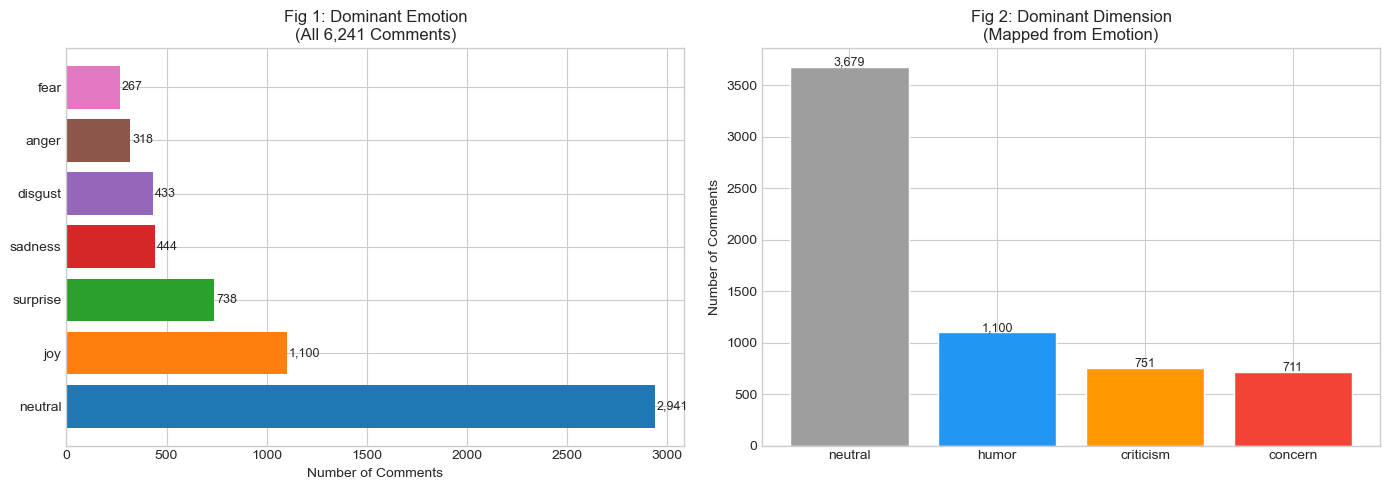

In [15]:
dim_map = {
    "joy":      "humor",
    "surprise": "neutral",
    "anger":    "criticism",
    "disgust":  "criticism",
    "fear":     "concern",
    "sadness":  "concern",
    "neutral":  "neutral",
}
df["dominant_dimension"] = df["dominant_emotion"].map(dim_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 1: Raw emotion distribution
emotion_counts = df["dominant_emotion"].value_counts()
colors_tab10 = plt.cm.tab10.colors
axes[0].barh(emotion_counts.index, emotion_counts.values,
             color=colors_tab10[:len(emotion_counts)])
axes[0].set_xlabel("Number of Comments")
axes[0].set_title("Fig 1: Dominant Emotion\n(All 6,241 Comments)")
for i, v in enumerate(emotion_counts.values):
    axes[0].text(v + 10, i, f"{v:,}", va="center", fontsize=9)

# Fig 2: Research dimension distribution
dim_counts = df["dominant_dimension"].value_counts()
dim_colors = {"humor": "#2196F3", "concern": "#F44336",
              "criticism": "#FF9800", "neutral": "#9E9E9E"}
bar_colors = [dim_colors.get(d, "#888888") for d in dim_counts.index]
axes[1].bar(dim_counts.index, dim_counts.values, color=bar_colors, edgecolor="white")
axes[1].set_ylabel("Number of Comments")
axes[1].set_title("Fig 2: Dominant Dimension\n(Mapped from Emotion)")
for i, (d, v) in enumerate(dim_counts.items()):
    axes[1].text(i, v + 15, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig1_2_corpus_emotion_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


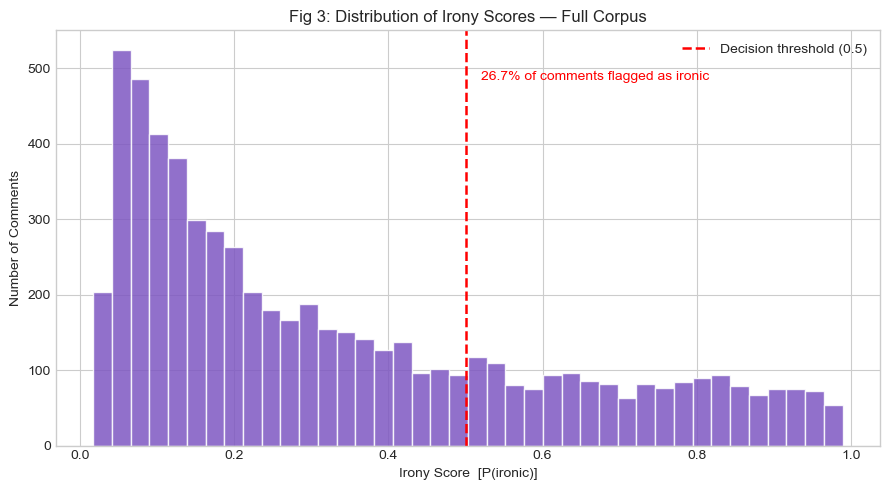

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["irony_score"], bins=40, color="#7E57C2", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.8, label="Decision threshold (0.5)")
ax.set_xlabel("Irony Score  [P(ironic)]")
ax.set_ylabel("Number of Comments")
ax.set_title("Fig 3: Distribution of Irony Scores — Full Corpus")
ax.legend()
pct = df["irony_flag"].mean() * 100
ax.annotate(
    f"{pct:.1f}% of comments flagged as ironic",
    xy=(0.52, ax.get_ylim()[1] * 0.88),
    color="red", fontsize=10
)
plt.tight_layout()
plt.savefig("fig3_irony_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 7 — Per-Category Sentiment Analysis

Only the keyword-tagged subset (~22.5% of comments) is used in this section. Three visualisations provide progressively finer resolution: aggregated dimension means (Fig 4), proportion of dominant emotions per category (Fig 5), and a full heatmap of all seven raw emotion scores (Fig 6).


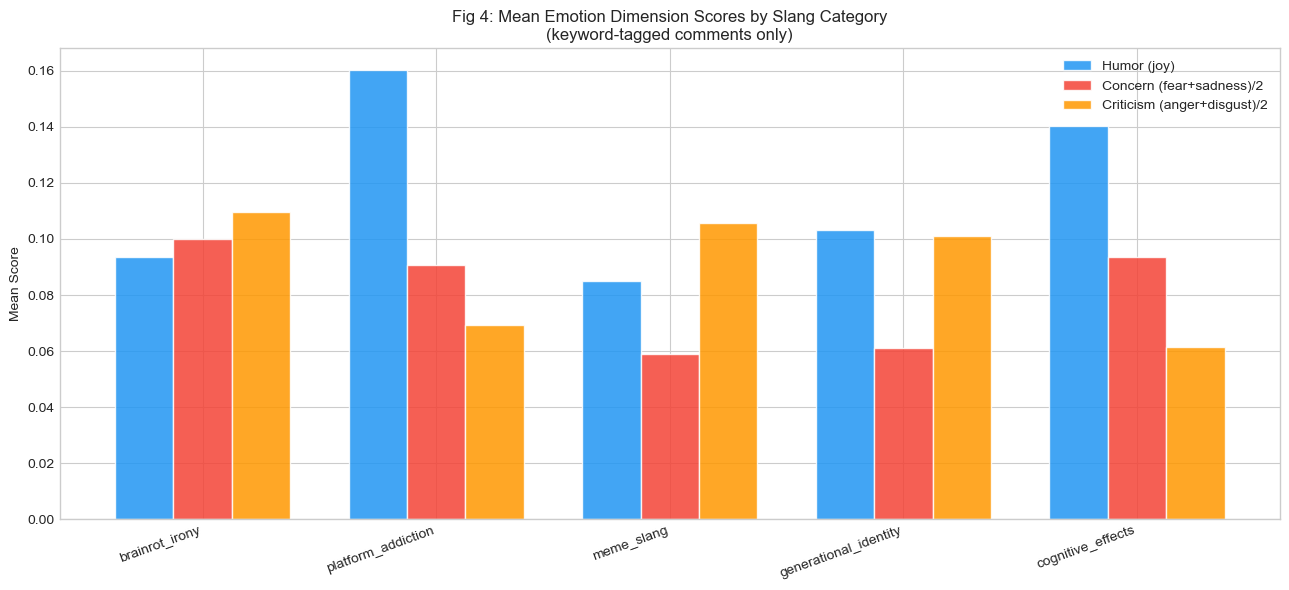

In [17]:
cat_order = ["brainrot_irony", "platform_addiction", "meme_slang",
             "generational_identity", "cognitive_effects"]
dims = ["humor_score", "concern_score", "criticism_score"]
dim_labels = ["Humor (joy)", "Concern (fear+sadness)/2", "Criticism (anger+disgust)/2"]
dim_colors_list = ["#2196F3", "#F44336", "#FF9800"]

cat_means = df_exploded.groupby("category")[dims].mean().reindex(cat_order)

x = np.arange(len(cat_means))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
for i, (dim, label, color) in enumerate(zip(dims, dim_labels, dim_colors_list)):
    ax.bar(x + i * width, cat_means[dim], width, label=label,
           color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(cat_order, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Mean Score")
ax.set_title("Fig 4: Mean Emotion Dimension Scores by Slang Category\n(keyword-tagged comments only)")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_dimension_scores_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


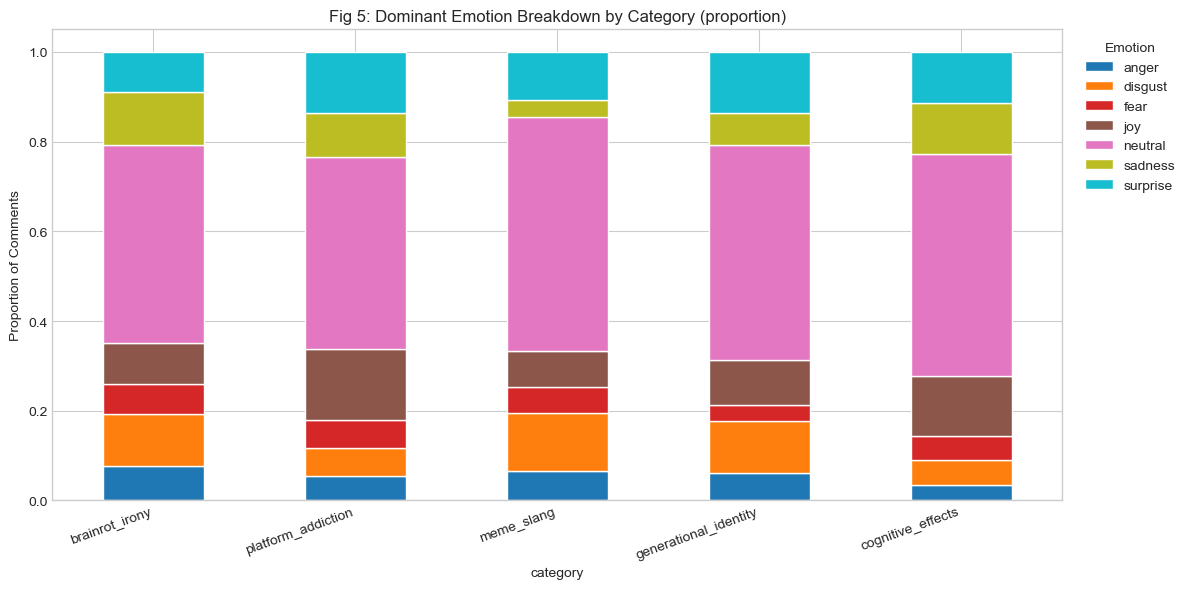

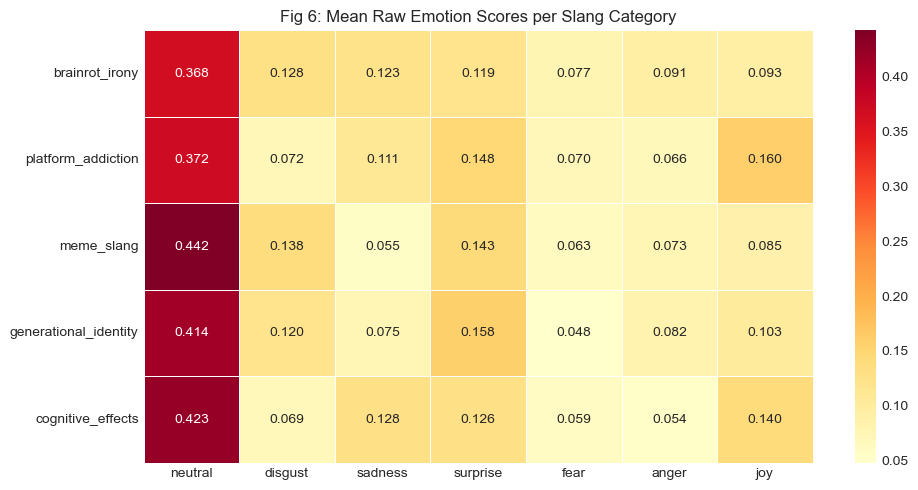

In [18]:
# Fig 5: Stacked 100% bar — dominant emotion per category
cat_emo = (
    df_exploded.groupby("category")["dominant_emotion"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(cat_order)
)
cat_emo.plot(
    kind="bar", stacked=True, figsize=(12, 6),
    colormap="tab10", edgecolor="white"
)
plt.title("Fig 5: Dominant Emotion Breakdown by Category (proportion)")
plt.ylabel("Proportion of Comments")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Emotion", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("fig5_emotion_breakdown_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 6: Heatmap of all 7 raw emo_* means per category
heatmap_data = (
    df_exploded.groupby("category")[raw_emo_cols].mean()
    .reindex(cat_order)
)
heatmap_data.columns = [c.replace("emo_", "") for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f",
    cmap="YlOrRd", linewidths=0.5, ax=ax
)
ax.set_title("Fig 6: Mean Raw Emotion Scores per Slang Category")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig6_emotion_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 8 — Research Question Analysis

### RQ1: Do meme slang comments skew ironic or humorous?

**Hypothesis direction:** Comments containing meme slang (`skibidi`, `rizz`, `gyatt`, etc.) should show elevated `humor_score` and `irony_score` relative to the full corpus.

**Test:** Independent-samples t-test on `humor_score` (meme_slang subset vs corpus). Cohen's d effect size reported alongside p-value.


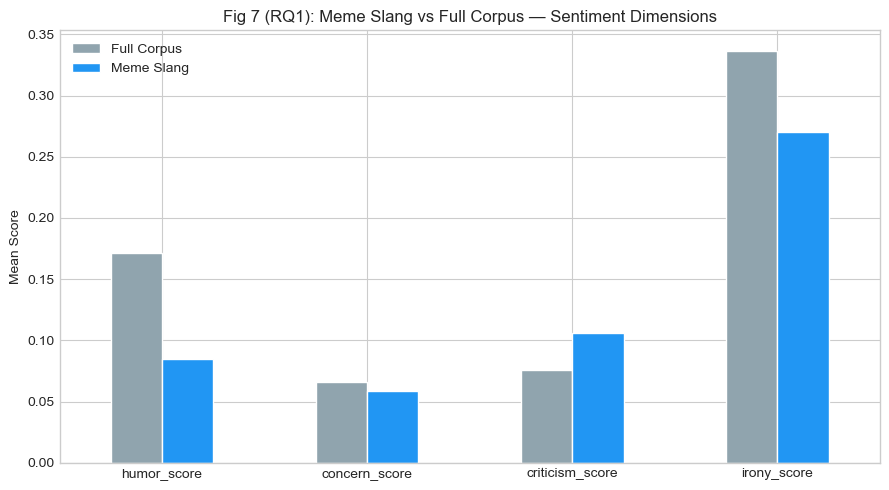

Meme slang subset: n=277
Humor score — meme: 0.0849  |  corpus: 0.1717
t-test: t=-4.924, p=0.0000
Cohen's d: -0.3023  (|d|<0.2 small, 0.5 medium, 0.8 large)


In [19]:
meme_df = df_exploded[df_exploded["category"] == "meme_slang"]
metrics = ["humor_score", "concern_score", "criticism_score", "irony_score"]

corpus_means = df[metrics].mean()
meme_means   = meme_df[metrics].mean()

compare_df = pd.DataFrame({"Full Corpus": corpus_means, "Meme Slang": meme_means})
compare_df.plot(
    kind="bar", figsize=(9, 5),
    color=["#90A4AE", "#2196F3"], edgecolor="white", rot=0
)
plt.title("Fig 7 (RQ1): Meme Slang vs Full Corpus — Sentiment Dimensions")
plt.ylabel("Mean Score")
plt.tight_layout()
plt.savefig("fig7_rq1_meme_slang_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# t-test and Cohen's d for humor_score
meme_humor   = meme_df["humor_score"].dropna()
corpus_humor = df["humor_score"].dropna()
t, p = stats.ttest_ind(meme_humor, corpus_humor)
pooled_std = np.sqrt(
    ((len(meme_humor) - 1) * meme_humor.std()**2 +
     (len(corpus_humor) - 1) * corpus_humor.std()**2)
    / (len(meme_humor) + len(corpus_humor) - 2)
)
cohens_d = (meme_humor.mean() - corpus_humor.mean()) / pooled_std

print(f"Meme slang subset: n={len(meme_humor):,}")
print(f"Humor score — meme: {meme_humor.mean():.4f}  |  corpus: {corpus_humor.mean():.4f}")
print(f"t-test: t={t:.3f}, p={p:.4f}")
print(f"Cohen's d: {cohens_d:.4f}  (|d|<0.2 small, 0.5 medium, 0.8 large)")


### RQ2: Do cognitive effects and platform addiction comments skew toward concern?

**Hypothesis direction:** Comments referencing `adhd`, `boredom`, `attention span`, `dopamine`, `scrolling` should show higher `concern_score` than other categories.

**Test:** Box plots of `concern_score` across all five categories. Highlighted categories: `cognitive_effects` (red) and `platform_addiction` (orange).


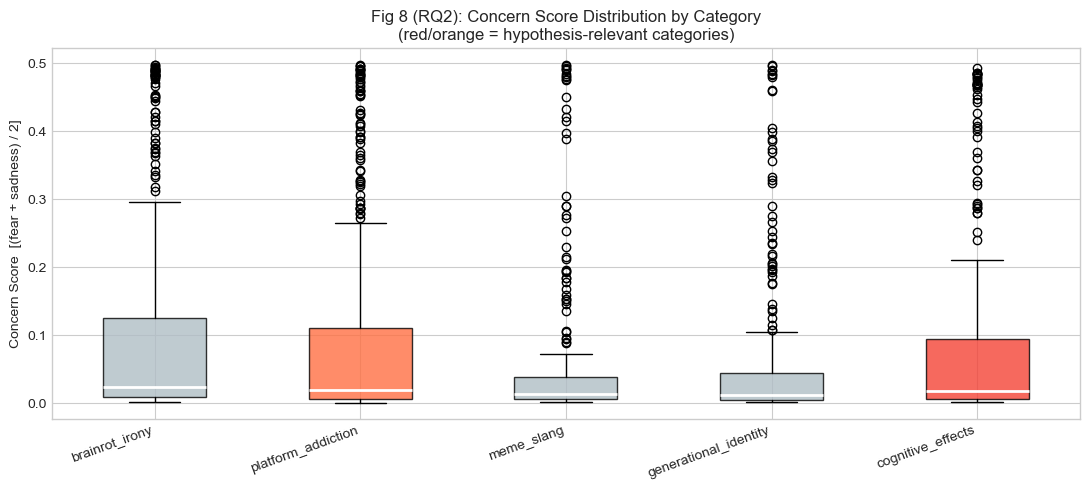

Median concern_score per category:
  brainrot_irony             median=0.0238  n=401
  platform_addiction         median=0.0189  n=430
  meme_slang                 median=0.0135  n=277
  generational_identity      median=0.0123  n=278
  cognitive_effects          median=0.0178  n=264


In [20]:
highlight_colors = {
    "cognitive_effects":     "#F44336",
    "platform_addiction":    "#FF7043",
    "brainrot_irony":        "#B0BEC5",
    "meme_slang":            "#B0BEC5",
    "generational_identity": "#B0BEC5",
}

concern_data = [
    df_exploded[df_exploded["category"] == c]["concern_score"].values
    for c in cat_order
]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(
    concern_data, labels=cat_order,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2)
)
for patch, cat in zip(bp["boxes"], cat_order):
    patch.set_facecolor(highlight_colors[cat])
    patch.set_alpha(0.8)

ax.set_xticklabels(cat_order, rotation=20, ha="right")
ax.set_ylabel("Concern Score  [(fear + sadness) / 2]")
ax.set_title("Fig 8 (RQ2): Concern Score Distribution by Category\n(red/orange = hypothesis-relevant categories)")
plt.tight_layout()
plt.savefig("fig8_rq2_concern_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median concern_score per category:")
for cat, data in zip(cat_order, concern_data):
    print(f"  {cat:<25}  median={np.median(data):.4f}  n={len(data):,}")


### RQ3: Does irony co-occur with concern within individual comments?

**Hypothesis direction:** If users express ironic anxiety — using meme language *while* also expressing worry — we expect a positive correlation between `irony_score` and `concern_score`.

**Tests:**
1. Pearson r (linear correlation)
2. Chi-square on a 2×2 contingency table: ironic/non-ironic × high-concern/low-concern

**Threshold rationale:** `irony_flag = irony_score ≥ 0.5` (natural binary classifier midpoint). `concern_flag = concern_score ≥ 0.3` — concern is rarely the dominant emotion, so 0.3 captures meaningful elevation without requiring it to be the top signal.


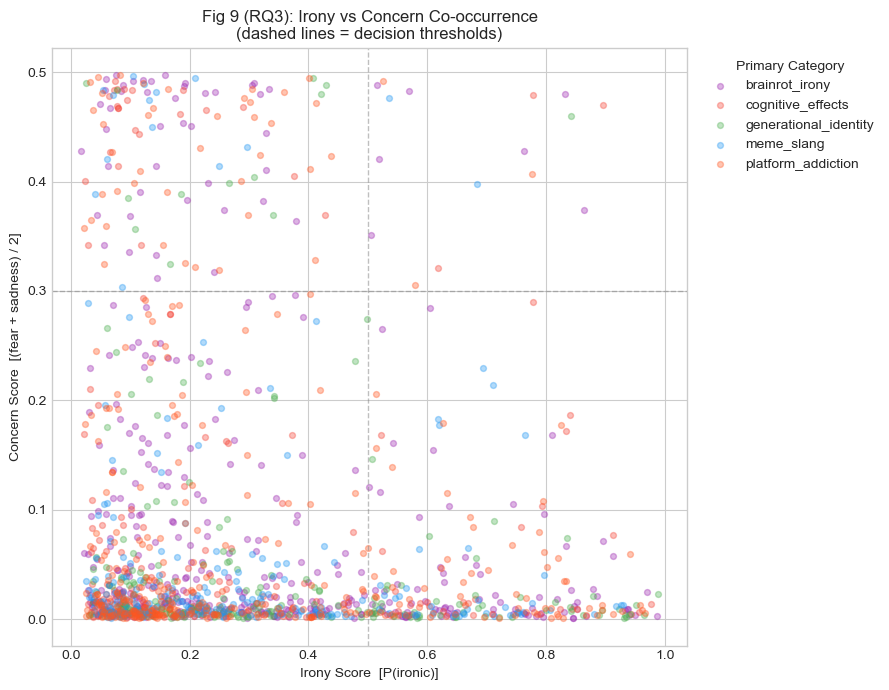

Pearson r(irony_score, concern_score) = -0.1244,  p = 0.0000
r > 0 = more ironic comments also tend to be more concerned.


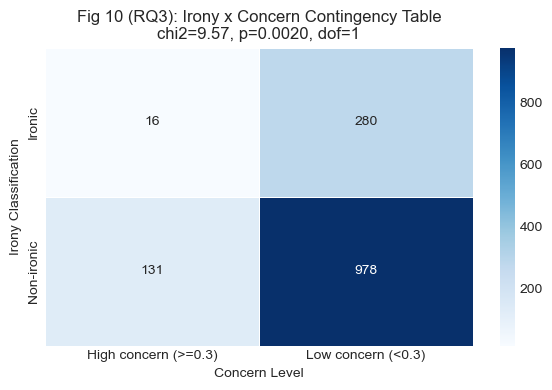


Contingency table:
concern_flag  High concern (>=0.3)  Low concern (<0.3)
irony_flag                                            
Ironic                          16                 280
Non-ironic                     131                 978


In [21]:
tagged_df = df[df["primary_category"] != "no_category"].copy()
tagged_df["concern_flag"] = (tagged_df["concern_score"] >= 0.3).astype(int)

cat_scatter_colors = {
    "brainrot_irony":        "#9C27B0",
    "platform_addiction":    "#FF5722",
    "meme_slang":            "#2196F3",
    "generational_identity": "#4CAF50",
    "cognitive_effects":     "#F44336",
}

# Fig 9: Scatter — irony vs concern
fig, ax = plt.subplots(figsize=(9, 7))
for cat, grp in tagged_df.groupby("primary_category"):
    ax.scatter(
        grp["irony_score"], grp["concern_score"],
        alpha=0.35, s=18, label=cat,
        color=cat_scatter_colors.get(cat, "#888888")
    )
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(0.3, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xlabel("Irony Score  [P(ironic)]")
ax.set_ylabel("Concern Score  [(fear + sadness) / 2]")
ax.set_title("Fig 9 (RQ3): Irony vs Concern Co-occurrence\n(dashed lines = decision thresholds)")
ax.legend(title="Primary Category", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("fig9_rq3_irony_concern_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Pearson correlation
r, p_r = stats.pearsonr(tagged_df["irony_score"], tagged_df["concern_score"])
print(f"Pearson r(irony_score, concern_score) = {r:.4f},  p = {p_r:.4f}")
print("r > 0 = more ironic comments also tend to be more concerned.")

# Fig 10: Contingency heatmap + chi-square
ct = pd.crosstab(
    tagged_df["irony_flag"].map({0: "Non-ironic", 1: "Ironic"}),
    tagged_df["concern_flag"].map({0: "Low concern (<0.3)", 1: "High concern (>=0.3)"})
)
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title(
    f"Fig 10 (RQ3): Irony x Concern Contingency Table\n"
    f"chi2={chi2:.2f}, p={p_chi:.4f}, dof={dof}"
)
ax.set_xlabel("Concern Level")
ax.set_ylabel("Irony Classification")
plt.tight_layout()
plt.savefig("fig10_rq3_contingency.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nContingency table:")
print(ct)


## Section 9 — Engagement Analysis

`comment_like_count` is used as a proxy for audience resonance. The distribution is heavily right-skewed (median ≈ 2, max > 100,000), so log₁₊ₓ transformation is applied. Kruskal-Wallis is used instead of ANOVA because like counts violate normality even after transformation.


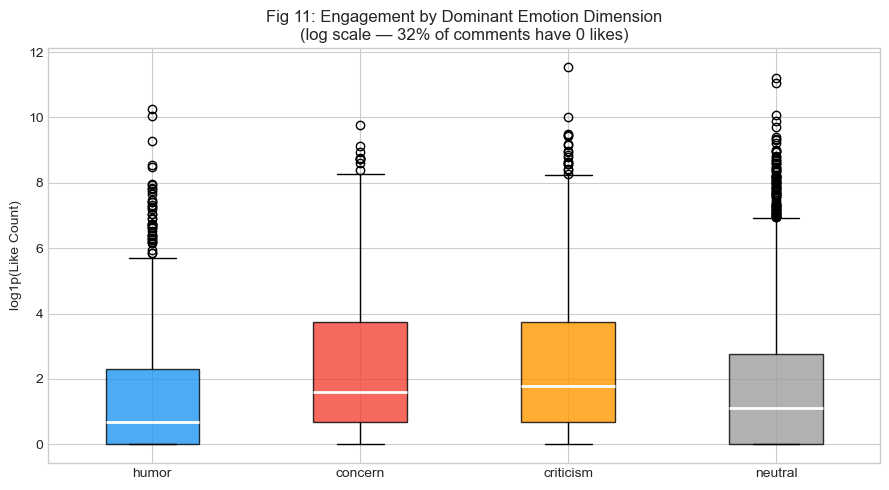

Kruskal-Wallis H = 149.59,  p = 0.0000
p < 0.05 = engagement differs significantly across emotion dimensions.

Median log1p(likes) per dimension:
  humor         median=0.693  n=1,100
  concern       median=1.609  n=711
  criticism     median=1.792  n=751
  neutral       median=1.099  n=3,679


In [22]:
from scipy.stats import kruskal

dims_order = ["humor", "concern", "criticism", "neutral"]
like_data = [
    np.log1p(df[df["dominant_dimension"] == d]["comment_like_count"].dropna().values)
    for d in dims_order
]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    like_data, labels=dims_order,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2)
)
palette = ["#2196F3", "#F44336", "#FF9800", "#9E9E9E"]
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel("log1p(Like Count)")
ax.set_title("Fig 11: Engagement by Dominant Emotion Dimension\n(log scale — 32% of comments have 0 likes)")
plt.tight_layout()
plt.savefig("fig11_engagement_by_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

valid_data = [d for d in like_data if len(d) > 1]
stat, p_kw = kruskal(*valid_data)
print(f"Kruskal-Wallis H = {stat:.2f},  p = {p_kw:.4f}")
print("p < 0.05 = engagement differs significantly across emotion dimensions.")

print("\nMedian log1p(likes) per dimension:")
for dim, data in zip(dims_order, like_data):
    print(f"  {dim:<12}  median={np.median(data):.3f}  n={len(data):,}")


## Section 10 — Per-Video Sentiment

The 22 videos have different editorial angles. Videos framing the topic around harm should attract higher `concern_score` comment sections; videos analysing meme humour should attract more ironic/playful comments.


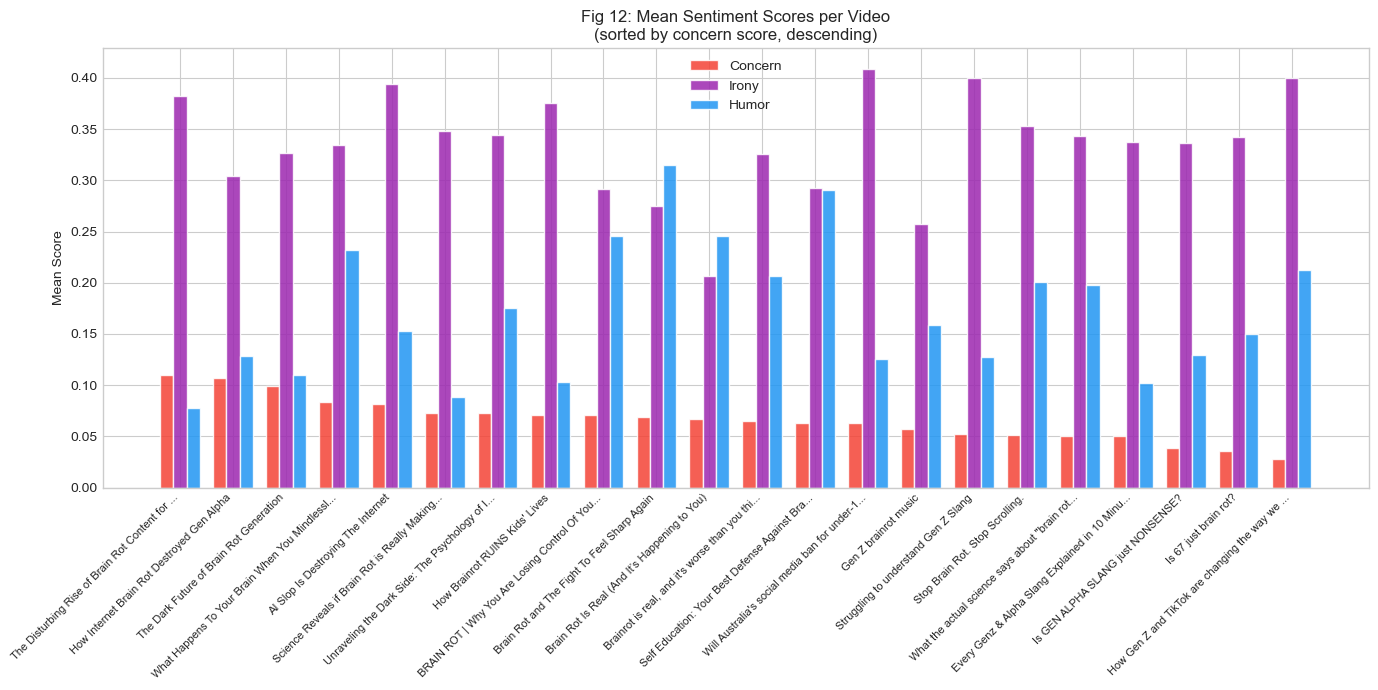

In [23]:
video_means = (
    df.groupby("video_title")[["concern_score", "irony_score", "humor_score"]]
    .mean()
    .sort_values("concern_score", ascending=False)
)

video_means.index = [
    t[:45] + "..." if len(t) > 45 else t
    for t in video_means.index
]

x = np.arange(len(video_means))
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - 0.25, video_means["concern_score"], 0.25,
       label="Concern", color="#F44336", alpha=0.85, edgecolor="white")
ax.bar(x,         video_means["irony_score"],   0.25,
       label="Irony",   color="#9C27B0", alpha=0.85, edgecolor="white")
ax.bar(x + 0.25,  video_means["humor_score"],   0.25,
       label="Humor",   color="#2196F3", alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(video_means.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean Score")
ax.set_title("Fig 12: Mean Sentiment Scores per Video\n(sorted by concern score, descending)")
ax.legend()
plt.tight_layout()
plt.savefig("fig12_per_video_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 11 — Summary and Conclusions

*(Fill in after running all cells.)*

---

### RQ1: Meme Slang and Humor/Irony
**Finding:** [Report whether meme_slang showed elevated humor_score. State t=..., p=..., Cohen's d=...]

**Interpretation:** If p < 0.05 and d > 0.2: meme slang comments are statistically more humorous than the general corpus, supporting the hypothesis. If not significant: slang terms like "sus" and "slay" may appear in neutral descriptive contexts as often as ironic ones.

---

### RQ2: Cognitive Effects / Platform Addiction and Concern
**Finding:** [Report whether cognitive_effects and platform_addiction showed higher median concern_score. Reference Fig 8.]

**Interpretation:** If elevated: comments about ADHD and dopamine reflect genuine anxiety about overstimulation. If mixed: words like "focus" also appear in positive/motivational contexts, diluting the signal.

---

### RQ3: Irony–Concern Co-occurrence
**Finding:** [Report Pearson r and chi-square. Note whether the high-irony + high-concern quadrant in Fig 9 is populated.]

**Interpretation:**
- r > 0, p < 0.05 → irony and concern co-occur — supports "ironic anxiety" hypothesis
- r ≈ 0 → irony and concern are orthogonal — the two modes may exist in separate discourse communities
- r < 0 → irony may function as deflection rather than co-expression

---

### Overall Verdict
[Synthesise the three RQs. Be honest about partial vs full support. If RQ3 shows no co-occurrence, the hypothesis may need reframing: irony and concern are both present in the corpus, but in different comments from different users rather than within the same comment.]

---

### Limitations Reiterated
1. Irony model domain mismatch (Twitter 2018 vs YouTube)
2. Keyword coverage limited to ~22.5% of corpus
3. Higher concern in cognitive_effects may reflect self-selection bias (worried users seek out those videos)
4. Emotion scores are probabilistic — small mean differences may not reflect meaningful experiential differences
